In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
    classification_report,f1_score,confusion_matrix)
import math
import matplotlib.pyplot as plt
import seaborn as sns

# PRA PROSES

In [2]:
gizi_bayat=pd.read_csv('https://drive.google.com/uc?id=1_a6uKLJrEqF90wmkNuTxgt2wTBCbKmkv')
gizi_kaggle=pd.read_csv('https://drive.google.com/uc?id=1x0qhULl__-JKq8_n4-nkF7qtH-8hIRix')

In [4]:
gizi_bayat.rename(columns={'Usia Saat Ukur': 'Usia'}, inplace=True)
target='Status Gizi'
fitur=['JK','Usia','Berat','Tinggi','LiLA']
x_kaggle=gizi_kaggle[fitur]
x_puskesmas=gizi_bayat[fitur]
y_kaggle=gizi_kaggle[target]
y_puskesmas=gizi_bayat[target]
x_gizi = pd.concat([x_kaggle, x_puskesmas], axis=0, ignore_index=True)
y_gizi = pd.concat([y_kaggle, y_puskesmas], axis=0, ignore_index=True)
gizi_df = x_gizi.copy()
gizi_df['Status Gizi'] = y_gizi.values
gizi_df.info()
gizi_df.to_csv('gizi_df.csv', index=False)
gizi_df.to_excel('gizi_df.xlsx', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2759 entries, 0 to 2758
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   JK           2759 non-null   object 
 1   Usia         2759 non-null   object 
 2   Berat        2759 non-null   float64
 3   Tinggi       2759 non-null   float64
 4   LiLA         1935 non-null   float64
 5   Status Gizi  2759 non-null   object 
dtypes: float64(3), object(3)
memory usage: 129.5+ KB


In [5]:
mapping_gizi = {
    'Gizi Buruk': 'Gizi Kurang',
    'Gizi Kurang': 'Gizi Kurang',
    'Gizi Lebih': 'Gizi Lebih',
    'Resiko Gizi Lebih': 'Gizi Lebih',
    'Risiko Gizi Lebih': 'Gizi Lebih',
    'Obesitas': 'Gizi Lebih',
    'Gizi Baik': 'Gizi Baik'
}
gizi_df['Status Gizi'] = gizi_df['Status Gizi'].map(mapping_gizi)
gizi_df['Status Gizi'].value_counts()

Status Gizi
Gizi Baik      1683
Gizi Kurang     721
Gizi Lebih      355
Name: count, dtype: int64

#PREPROCESING

##Missing Value

In [6]:
gizi_df.isna().sum()

JK               0
Usia             0
Berat            0
Tinggi           0
LiLA           824
Status Gizi      0
dtype: int64

# Imputasi mean

In [7]:
missing_value = gizi_df.mean(numeric_only=True)
gizi_df= gizi_df.fillna(missing_value)
df_imputasi=gizi_df.copy()
gizi_df.isna().sum()

JK             0
Usia           0
Berat          0
Tinggi         0
LiLA           0
Status Gizi    0
dtype: int64

In [8]:
gizi_df.head(10)

,JK,Usia,Berat,Tinggi,LiLA,Status Gizi
0,P,4 tahun,8.3,79.5,0.000000,Gizi Kurang
1,P,5 tahun,9.7,85.6,0.000000,Gizi Kurang
2,L,6 tahun,11.0,92.5,14.400000,Gizi Kurang
3,L,3 tahun,5.7,57.0,10.190336,Gizi Lebih
4,P,6 tahun,8.6,78.4,13.500000,Gizi Baik
5,L,5 tahun,8.9,78.0,14.000000,Gizi Baik
6,L,5 tahun,8.2,75.0,14.000000,Gizi Kurang
7,P,5 tahun,8.2,79.0,13.500000,Gizi Kurang
8,L,5 tahun,9.6,85.0,14.500000,Gizi Kurang
9,L,3 tahun,7.1,70.3,15.500000,Gizi Kurang


# Transformasi

In [9]:
def conv_usia(usia):
    if str(usia).isdigit():
        return int(usia)
    match = re.findall(r'\d+', str(usia))
    format = str(usia).lower()
    if len(match) == 1:
        nilai = int(match[0])
        if 'bulan' in format or 'bln' in format:
            return nilai
        elif 'hari' in format:
            return round(nilai / 30.4375)
        elif 'tahun' in format or 'th' in format:
            return nilai * 12
        else:
            return nilai
    elif len(match) == 2:
      a, b = map(int, match)
      if 'tahun' in format and 'bulan' in format:
          if format.index('tahun') < format.index('bulan'):
              tahun, bulan = a, b
          else:
              bulan, tahun = a, b
          return tahun * 12 + bulan
      if 'hari' in format and 'bulan' in format:
          if format.index('hari') < format.index('bulan'):
              hari, bulan = a, b
          else:
              bulan, hari = a, b
          return int(round(hari/30.4375 + bulan))
      if 'hari' in format and 'tahun' in format:
          if format.index('hari') < format.index('tahun'):
              hari, tahun = a, b
          else:
              tahun, hari = a, b
          return int(round(hari/30.4375 + tahun * 12))

    elif len(match) >= 3:
        tahun, bulan, hari = map(int, match)
        total_bulan = tahun*12 + bulan + hari/30.4375
        return round(total_bulan, 1)
    return None

gizi_df["Usia"] = gizi_df["Usia"].apply(conv_usia)
df_conv= gizi_df.copy()
gizi_df.head()

,JK,Usia,Berat,Tinggi,LiLA,Status Gizi
0,P,48.0,8.3,79.5,0.000000,Gizi Kurang
1,P,60.0,9.7,85.6,0.000000,Gizi Kurang
2,L,72.0,11.0,92.5,14.400000,Gizi Kurang
3,L,36.0,5.7,57.0,10.190336,Gizi Lebih
4,P,72.0,8.6,78.4,13.500000,Gizi Baik


# Normalisasi MinMax

In [10]:
scaler=MinMaxScaler()
kolom_numerik=gizi_df.select_dtypes(include='number').columns
gizi_df[kolom_numerik]= scaler.fit_transform(gizi_df[kolom_numerik])
df_scaling=gizi_df.copy()
gizi_df.head()

,JK,Usia,Berat,Tinggi,LiLA,Status Gizi
0,P,0.500,0.229927,0.472603,0.000000,Gizi Kurang
1,P,0.625,0.281022,0.556164,0.000000,Gizi Kurang
2,L,0.750,0.328467,0.650685,0.282353,Gizi Kurang
3,L,0.375,0.135036,0.164384,0.199811,Gizi Lebih
4,P,0.750,0.240876,0.457534,0.264706,Gizi Baik


# Label Encoding

In [12]:
kolom_encode=gizi_df.select_dtypes(include="object").columns
encoders={}
for col in kolom_encode:
    lencoding=LabelEncoder()
    gizi_df[col] = (gizi_df[col].str.strip())
    gizi_df[col]=lencoding.fit_transform(gizi_df[col])
    encoders[col] = lencoding
    print(f"Kolom {col}:")
    for label, encoded in zip(lencoding.classes_, range(len(lencoding.classes_))):
        print(f"  {label} → {encoded}")
    print()
print("\nData setelah label encoding:")
df_encode=gizi_df.copy()
print(gizi_df.head())


Data setelah label encoding:
   JK   Usia     Berat    Tinggi      LiLA  Status Gizi
0   1  0.500  0.229927  0.472603  0.000000            1
1   1  0.625  0.281022  0.556164  0.000000            1
2   0  0.750  0.328467  0.650685  0.282353            1
3   0  0.375  0.135036  0.164384  0.199811            2
4   1  0.750  0.240876  0.457534  0.264706            0


# LOF

In [13]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination='auto'
)
gizi_df['LOF_label'] = lof.fit_predict(gizi_df)
gizi_df['LOF_score'] = lof.negative_outlier_factor_
df_outlier=gizi_df.copy()
jumlah_outlier = (gizi_df['LOF_label'] == -1).sum()
print("Jumlah data terindikasi outlier:", jumlah_outlier)

Jumlah data terindikasi outlier: 174


In [14]:
df_gizi= gizi_df[gizi_df['LOF_label'] == 1].copy()
df_gizi.drop(columns=['LOF_label', 'LOF_score'], inplace=True)
print("Jumlah data awal :", len(gizi_df))
print("Jumlah data setelah hapus outlier :", len(df_gizi))

Jumlah data awal : 2759
Jumlah data setelah hapus outlier : 2585


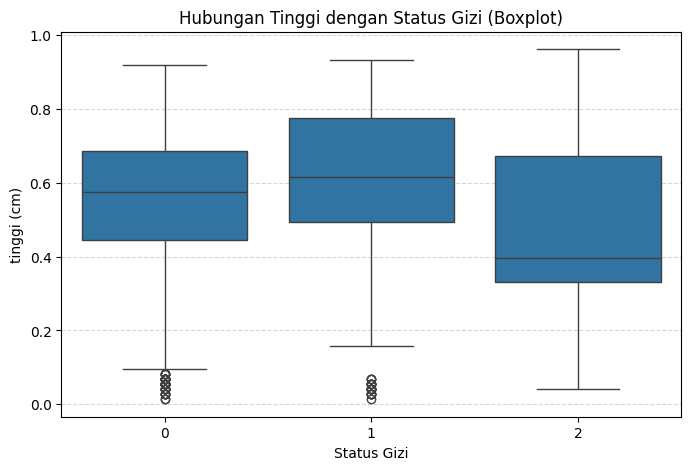

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_gizi, x='Status Gizi', y='Tinggi')

plt.title('Hubungan Tinggi dengan Status Gizi (Boxplot)')
plt.xlabel('Status Gizi')
plt.ylabel('tinggi (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


# Split Data

In [16]:
y=df_gizi['Status Gizi']
x=df_gizi[['JK','Usia','Berat','Tinggi','LiLA']]
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.10 , random_state=42)
print(f'Jumlah total data = {len(df_gizi)}')
print (f' Split data training = {len(X_train)}')
print (f' Split data testing = {len(y_test)}')
y_train.value_counts()

Jumlah total data = 2585
 Split data training = 2326
 Split data testing = 259


Status Gizi
0    1434
1     608
2     284
Name: count, dtype: int64

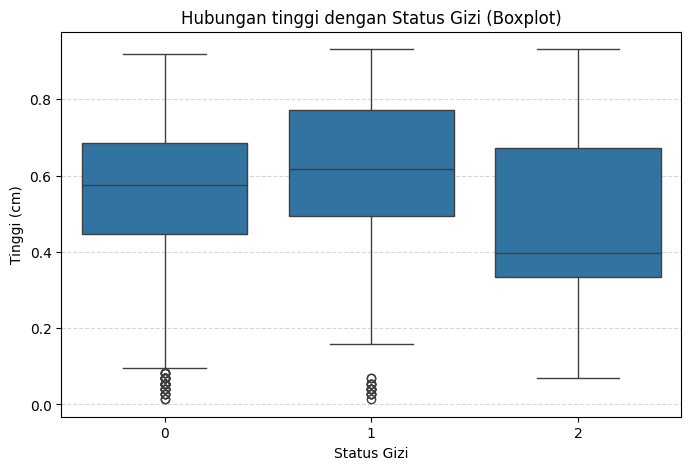

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

gizi_train=X_train.copy()
gizi_train['Status Gizi']=y_train
plt.figure(figsize=(8, 5))
sns.boxplot(data=gizi_train, x='Status Gizi', y='Tinggi')

plt.title('Hubungan tinggi dengan Status Gizi (Boxplot)')
plt.xlabel('Status Gizi')
plt.ylabel('Tinggi (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


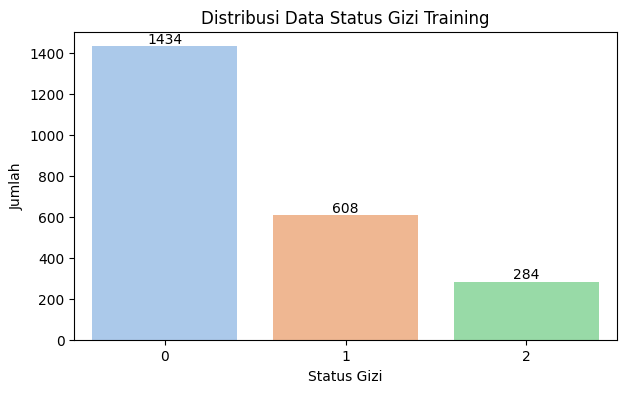

In [18]:
plt.figure(figsize=(7,4))
ax = sns.countplot(x=y_train, palette='pastel', hue=y_train, legend=False)
plt.title('Distribusi Data Status Gizi Training')
plt.xlabel('Status Gizi')
plt.ylabel('Jumlah')
for n in ax.patches:
  ax.text(
      n.get_x() + n.get_width()/2,
      n.get_height(),
      int(n.get_height()),
      ha='center', va='bottom'
  )

# SMOTE-ENN

In [19]:
k_smote=SMOTE(k_neighbors=3)
k_enn=EditedNearestNeighbours(n_neighbors=5)
smoten= SMOTEENN(random_state=42, smote=k_smote, enn=k_enn)
X_res, y_res = smoten.fit_resample(X_train, y_train)
gizi_res = X_res.copy()
gizi_res['Status Gizi']=y_res
gizi_res['Status Gizi'].value_counts()

Status Gizi
0    1434
2    1330
1    1185
Name: count, dtype: int64

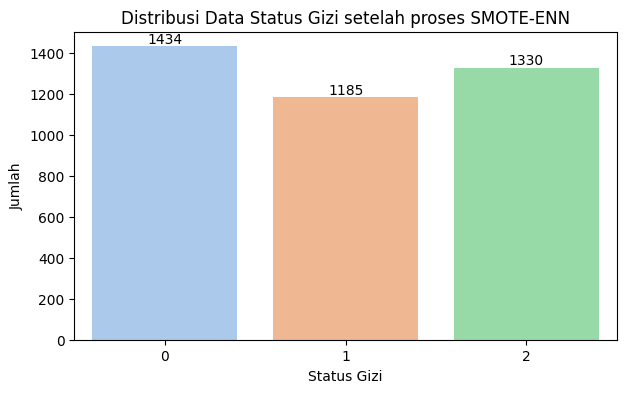

In [20]:
plt.figure(figsize=(7,4))
ax = sns.countplot(x=y_res, palette='pastel', hue=y_res, legend=False)
plt.title('Distribusi Data Status Gizi setelah proses SMOTE-ENN')
plt.xlabel('Status Gizi')
plt.ylabel('Jumlah')
for n in ax.patches:
  ax.text(
      n.get_x() + n.get_width()/2,
      n.get_height(),
      int(n.get_height()),
      ha='center', va='bottom'
  )

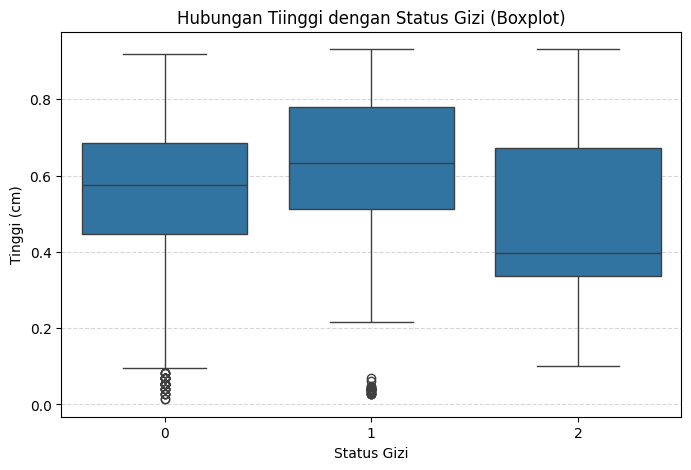

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=gizi_res, x='Status Gizi', y='Tinggi')

plt.title('Hubungan Tiinggi dengan Status Gizi (Boxplot)')
plt.xlabel('Status Gizi')
plt.ylabel('Tinggi (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


In [33]:
from collections import Counter

print("Sebelum:", Counter(y_train))
print("Sesudah SMOTE:", Counter(k_smote.fit_resample(X_train, y_train)[1]))
print("Sesudah SMOTE-ENN:", Counter(y_res))
print("="*50)
X_smote, y_smote=k_smote.fit_resample(X_train, y_train)
gizi_smote=X_smote.copy()
gizi_smote['Status Gizi']= y_smote

Sebelum: Counter({0: 1434, 1: 608, 2: 284})
Sesudah SMOTE: Counter({1: 1434, 2: 1434, 0: 1434})
Sesudah SMOTE-ENN: Counter({0: 1434, 2: 1330, 1: 1185})


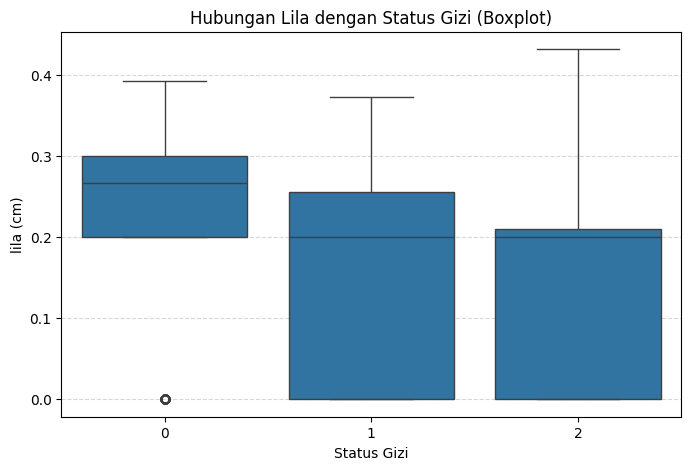

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=gizi_smote, x='Status Gizi', y='LiLA')

plt.title('Hubungan Lila dengan Status Gizi (Boxplot)')
plt.xlabel('Status Gizi')
plt.ylabel('lila (cm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Algoritma C5

In [44]:
kolom_kategorik=['JK','Status Gizi']
kolom_numerik=['Usia', 'Berat', 'Tinggi', 'LiLA']
fitur=['Usia', 'Berat', 'Tinggi', 'LiLA','JK']
def entropy(kolom,target):
    total_bobot = kolom['bobot'].sum()
    if total_bobot == 0:
        return 0
    entro = 0
    for a in kolom[target].unique():
        wi = kolom.loc[kolom[target] == a, 'bobot'].sum()
        pi = wi/total_bobot
        if pi > 0:
            entro -= pi * math.log2(pi)
    return entro
def infogain(gizi, atribut, target):
    entropi_s = entropy(gizi, target)
    entropi_si = 0
    total_bobot=gizi['bobot'].sum()
    if atribut in kolom_kategorik:
      kategori,jumlah = np.unique(gizi[atribut], return_counts=True)
      for a in range(len(kategori)):
          subset = gizi[gizi[atribut] == kategori[a]]
          wi= subset['bobot'].sum()
          entropi_si += (wi/total_bobot) * entropy(subset,target)
      information_gain = entropi_s - entropi_si
      return information_gain, None
    elif atribut in kolom_numerik:
      mean_val=gizi[atribut].mean()
      subset_kiri = gizi[gizi[atribut] < mean_val]
      subset_kanan = gizi[gizi[atribut] >= mean_val]
      if subset_kiri.empty or subset_kanan.empty:
        return 0, mean_val
      wi_kiri=subset_kiri['bobot'].sum()
      wi_kanan=subset_kanan['bobot'].sum()
      print(f"Subset kiri (≤{round(mean_val,4)}) : {len(subset_kiri)}")
      print(f"Subset kanan (>{round(mean_val,4)}) : {len(subset_kanan)}")
      entropi_si = (
          (wi_kiri/total_bobot) * entropy(subset_kiri,target) +
          (wi_kanan/total_bobot) * entropy(subset_kanan, target)
      )
      information_gain = entropi_s - entropi_si
      return information_gain, mean_val
def splitinfo_bobot(gizi, atribut):
  si=0
  if len(gizi) == 0:
    return 0
  total_bobot=gizi['bobot'].sum()
  if atribut in kolom_kategorik:
    for a in gizi[atribut].unique():
      wi=gizi.loc[gizi[atribut]==a, 'bobot'].sum()
      p=wi/total_bobot
      if p>0:
        si += (p*math.log2(p))
    return -si
  if atribut in kolom_numerik:
    mean_val=gizi[atribut].mean()
    subset_kiri = gizi[gizi[atribut] < mean_val]
    subset_kanan = gizi[gizi[atribut] >= mean_val]
    if subset_kiri.empty or subset_kanan.empty:
      return 0
    si=0
    for subdat in [subset_kiri, subset_kanan]:
      wi=subdat['bobot'].sum()
      p = wi / total_bobot
      if p > 0:
        si += p * math.log2(p)
    return -si
def gainratio_bobot(gizi, atribut, target):
    info_split=splitinfo_bobot(gizi, atribut)
    information_gain,mean_val = infogain(gizi, atribut, target)
    if information_gain <=0 or info_split<= 1e-9:
      return 0,mean_val
    print(f"{atribut} | IG={information_gain:.4f} | SI={info_split:.4f}")
    ratiogain=information_gain/info_split
    return ratiogain,mean_val

def mayoritas_kelas(gizi,target,default=None):
  if gizi.empty:
    return default
  return (gizi.groupby(target)['bobot'].sum().idxmax())

def tree(gizi, atribut, target, depth, depth_max):
  if len(gizi[target].unique())==1:
    return gizi[target].iloc[0]
  if depth==depth_max or len(atribut)==0:
    return mayoritas_kelas(gizi,target,default=mayoritas_kelas(gizi, target))
  # untuk mencari root dari gain ratio terbaik
  atribut_ter=None
  best_mean=None
  ratio_gain=-1
  for fitur in atribut:
      gainratio,mean_val= gainratio_bobot(gizi, fitur, target)
      if gainratio>ratio_gain:
        ratio_gain=gainratio
        best_mean=mean_val
        atribut_ter=fitur
  if ratio_gain <= 0:
    return mayoritas_kelas(gizi, target,default=mayoritas_kelas(gizi, target))
  if atribut_ter is None:
    return mayoritas_kelas(gizi,target, default=mayoritas_kelas(gizi, target))
  if atribut_ter in kolom_kategorik:
    next_atr= [atr for atr in atribut if atr != atribut_ter]
    print(f'root pohon {atribut_ter} di kedalaman pohon {depth}')
    node= {'atribut': atribut_ter, 'gain ratio': ratio_gain}
    for a in gizi[atribut_ter].unique():
      subset= gizi[gizi[atribut_ter] == a]
      node[a]= tree(subset, [atr for atr in atribut if atr != atribut_ter], target, depth+1, depth_max)
  elif atribut_ter in kolom_numerik:
    next_atr=atribut[:]
    print(f'root pohon {atribut_ter} di kedalaman pohon {depth}')
    node= {'atribut': atribut_ter, 'mean':best_mean, 'gain ratio': ratio_gain}
    subset_kiri = gizi[gizi[atribut_ter] < best_mean]
    subset_kanan = gizi[gizi[atribut_ter] >= best_mean]
    node['kiri']  = tree(subset_kiri, next_atr, target, depth+1, depth_max)
    node['kanan'] = tree(subset_kanan, next_atr, target, depth+1, depth_max)
  return node

def prediksi_c50(baris, node, data_latih, target):
    if not isinstance(node, dict):
        return node
    atr = node['atribut']
    if atr in kolom_kategorik:
        nilai = baris[atr]
        if nilai in node:
            return prediksi_c50(baris, node[nilai], data_latih, target)
        else:
            return mayoritas_kelas(data_latih, target,default=mayoritas_kelas(data_latih, target))
    else:
        nilai = baris[atr]
        batas = node['mean']
        if nilai < batas:
            return prediksi_c50(baris, node['kiri'], data_latih, target)
        else:
            return prediksi_c50(baris, node['kanan'], data_latih, target)


In [45]:
t=50
depthmax=7
gizi_res['bobot'] = 1 / len(gizi_res)
tree_c50=(gizi_res, fitur, 'Status Gizi', 0, depthmax)

# ADABOOST

# ADABOOST M1

In [46]:
def adaboost(gizi,atribut,target,estimator,depthmax):
  model=[]
  beta=[]
  niror=[]
  for b in range(estimator):
    print(f'\n iterasi ke-{b+1}')
    tree_c50 = tree(gizi, atribut,'Status Gizi',depth=0, depth_max=depthmax)
    print(f'\n ==Pohon Algoritma C5.0 {tree_c50}')
    y_pred=gizi.apply(lambda x: prediksi_c50(x, tree_c50,gizi,target), axis=1)
    y_true=gizi[target]
    jum_er=(y_pred != y_true).astype(int)
    eror= np.sum(gizi['bobot']*jum_er)
    # if eror <= 0 or eror >= 0.5:
    #   print("Error tidak valid, stop iterasi")
    #   break
    fakeror=(eror/(1-eror))
    print(f'\n ==nilai faktorisasi eror {fakeror} dan eror {eror}')
    # update bobot
    gizi.loc[y_pred==y_true, 'bobot']*=fakeror
    gizi.loc[y_pred!=y_true, 'bobot']*=1
    # normalisasi bobot
    gizi['bobot']/=gizi['bobot'].sum()
    niror.append(eror)
    model.append(tree_c50)
    beta.append(fakeror)
  return model,beta,niror
def prediksi_adb(gizi,model,beta):
  hasil=[]
  for a in range(len(gizi)):
    vote_bobot={}
    for pohon,b in zip(model,beta):
      pred=prediksi_c50(gizi.iloc[a],pohon,gizi,target)
      vote_bobot[pred]=vote_bobot.get(pred,0)+np.log(1/b)
    hasil.append(max(vote_bobot, key=vote_bobot.get))
  return np.array(hasil)

In [47]:
model,beta,niror= adaboost(gizi_res,fitur,'Status Gizi',t,depthmax)


 iterasi ke-1
Subset kiri (≤0.4926) : 1610
Subset kanan (>0.4926) : 2339
Usia | IG=0.1312 | SI=0.9753
Subset kiri (≤0.3527) : 2100
Subset kanan (>0.3527) : 1849
Berat | IG=0.0162 | SI=0.9971
Subset kiri (≤0.5479) : 1895
Subset kanan (>0.5479) : 2054
Tinggi | IG=0.0580 | SI=0.9988
Subset kiri (≤0.1652) : 1352
Subset kanan (>0.1652) : 2597
LiLA | IG=0.1553 | SI=0.9271
JK | IG=0.0010 | SI=0.9804
root pohon LiLA di kedalaman pohon 0
Subset kiri (≤0.6399) : 857
Subset kanan (>0.6399) : 495
Usia | IG=0.4933 | SI=0.9476
Subset kiri (≤0.3318) : 585
Subset kanan (>0.3318) : 767
Berat | IG=0.0372 | SI=0.9869
Subset kiri (≤0.5184) : 771
Subset kanan (>0.5184) : 581
Tinggi | IG=0.6241 | SI=0.9857
JK | IG=0.0059 | SI=0.9808
root pohon Tinggi di kedalaman pohon 1
Subset kiri (≤0.5405) : 491
Subset kanan (>0.5405) : 280
Usia | IG=0.0075 | SI=0.9453
Subset kiri (≤0.2997) : 388
Subset kanan (>0.2997) : 383
Berat | IG=0.1817 | SI=1.0000
Subset kiri (≤0.3665) : 272
Subset kanan (>0.3665) : 499
Tinggi | 

In [48]:
test_df = X_test.copy()
test_df['Status Gizi'] = y_test.values

# Prediksi Testing
ypred_test_m1 = prediksi_adb(test_df, model, beta)
# Prediksi Training
ypred_train_m1 = prediksi_adb(gizi_res, model, beta)

akurasi_test = accuracy_score(y_test.values, ypred_test_m1)
akurasi_train = accuracy_score(
    gizi_res['Status Gizi'].values,
    ypred_train_m1
)
y_train_true = gizi_res['Status Gizi'].astype(int)
y_test_true  = y_test.astype(int)
y_train_pred = pd.Series(ypred_train_m1).astype(int)
y_test_pred  = pd.Series(ypred_test_m1).astype(int)
class_labels = sorted(y_train_true.unique())
def penilaian_bobot(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    hasil = []
    recalls = []
    for i, kelas in enumerate(labels):

        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        # Hitung dalam bentuk desimal
        precision_d = (TP / (TP + FP)) if (TP + FP) > 0 else 0
        recall_d = (TP / (TP + FN)) if (TP + FN) > 0 else 0
        specificity_d = (TN / (TN + FP)) if (TN + FP) > 0 else 0
        f1_d = (2 * precision_d * recall_d / (precision_d + recall_d)) \
               if (precision_d + recall_d) > 0 else 0
        gmean_d = np.sqrt(recall_d * specificity_d)
        recalls.append(recall_d)
        hasil.append([
            kelas,
            round(precision_d * 100, 2),
            round(recall_d * 100, 2),
            round(f1_d * 100, 2),
            round(specificity_d * 100, 2),
            round(gmean_d * 100, 2)
        ])
    # G-Mean Total (multiclass)
    gmean_total = (np.prod(recalls) ** (1 / len(recalls))) * 100
    df = pd.DataFrame(
        hasil,
        columns=[
            "Kelas",
            "Precision (%)",
            "Recall (%)",
            "F1-Score (%)",
            "Specificity (%)",
            "G-Mean (%)"
        ]
    )
    return df, cm, round(gmean_total, 2)
df_train, cm_train, gmean_train = penilaian_bobot(
    y_train_true,
    y_train_pred,
    class_labels
)
df_test, cm_test, gmean_test = penilaian_bobot(
    y_test_true,
    y_test_pred,
    class_labels
)
# Tambahkan info dataset
df_train["Dataset"] = "Data Training"
df_test["Dataset"] = "Data Testing"
# Gabungkan
df_nilai = pd.concat([df_train, df_test], ignore_index=True)
# Tambahkan Akurasi
df_nilai["Akurasi (%)"] = df_nilai["Dataset"].map({
    "Data Training": round(akurasi_train * 100, 2),
    "Data Testing": round(akurasi_test * 100, 2)
})
# Tambahkan G-Mean Total
df_nilai["G-Mean Total (%)"] = df_nilai["Dataset"].map({
    "Data Training": gmean_train,
    "Data Testing": gmean_test
})
print("Confusion Matrix Training:")
print(cm_train)
print("\nConfusion Matrix Testing:")
print(cm_test)
print("\nHasil Evaluasi:")
display(df_nilai)

Confusion Matrix Training:
[[1433    1    0]
 [   0 1185    0]
 [   0    0 1330]]

Confusion Matrix Testing:
[[165   0   3]
 [  9  52   0]
 [  0   0  30]]

Hasil Evaluasi:


,Kelas,Precision (%),Recall (%),F1-Score (%),Specificity (%),G-Mean (%),Dataset,Akurasi (%),G-Mean Total (%)
0,0,100.00,99.93,99.97,100.00,99.97,Data Training,99.97,99.98
1,1,99.92,100.00,99.96,99.96,99.98,Data Training,99.97,99.98
2,2,100.00,100.00,100.00,100.00,100.00,Data Training,99.97,99.98
3,0,94.83,98.21,96.49,90.11,94.07,Data Testing,95.37,94.25
4,1,100.00,85.25,92.04,100.00,92.33,Data Testing,95.37,94.25
5,2,90.91,100.00,95.24,98.69,99.34,Data Testing,95.37,94.25


In [49]:
classes = df_gizi[target].unique()
data_latih=gizi_res.copy()

In [50]:
import pickle

In [51]:
pickle.dump({      # dataframe hasil imputasi
    'dok_misval': df_imputasi,
    'dok_encoded': df_encode,
    'dok_scaled': df_scaling,
    'dok_usia' : df_conv,
    'dok_outlier' : df_outlier,
    'data_latih' : data_latih,
    'split': {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    },
    'input_features': X_train.columns.tolist(),
    'smoteenn': {
        'X_res': X_res,
        'y_res': y_res
    },
    'missing_value': missing_value,
    'encoder': encoders,
    'scaler': scaler,
     'algoritma.C5': {
        'depth': depthmax,
        'tree': tree_c50
    },
    'adaboost': {
        'models': model,
        'betas': beta,
        'classes': classes
    },
    'X_test': X_test,             
    'y_test': y_test,
    'X_smote': X_res,             
    'y_smote': y_res
}, open('model_gizi.sav', 'wb'))
